**Import Libraries**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

**Load Dataset**

In [2]:
df=pd.read_csv('flipkart_com-ecommerce_sample.csv')
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20002 entries, 0 to 20001
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  object 
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_specifications

In [4]:
df.isnull().sum()

uniq_id                       2
crawl_timestamp               2
product_url                   2
product_name                  2
product_category_tree         2
pid                           2
retail_price                 80
discounted_price             80
image                         5
is_FK_Advantage_product       2
description                   4
product_rating                2
overall_rating                2
brand                      5866
product_specifications       16
dtype: int64

**Data Preprocessing**

In [5]:
df['retail_price'].fillna(df['retail_price'].median(), inplace=True)
df['discounted_price'].fillna(df['discounted_price'].median(), inplace=True)
df['brand'].fillna(df['brand'].mode()[0], inplace=True)
df['product_category_tree'].fillna(df['product_category_tree'].mode(), inplace=True)

**Feature Engineering**

In [6]:
df['discount']=df['retail_price']-df['discounted_price']
df['discount_percent']= (df['discount']/df['retail_price'])*100
df['is_discounted'] = np.where(df['discount_percent'] > 0, 1, 0)


**Encode Categorical variables**

In [7]:
le_brand=LabelEncoder()
df['brand_encoded']=le_brand.fit_transform(df['brand'])

le_cat=LabelEncoder()
df['category_encoded']=le_cat.fit_transform(df['product_category_tree'].astype(str))
df.head()


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,discount,discount_percent,is_discounted,brand_encoded,category_encoded
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",620.0,62.062062,1,163,2417
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati...",9511.0,29.576764,1,919,3985
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""...",500.0,50.050050,1,70,3845
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",432.0,61.802575,1,163,2417
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",10.0,4.545455,1,2665,5786


**EDA(Exploratory Data Analysis)**

1. Retail price distribution

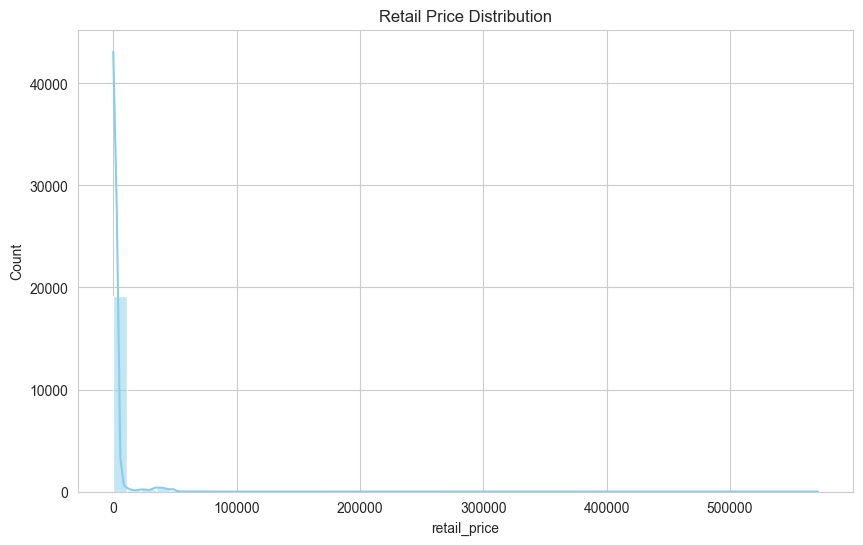

In [8]:
sns.histplot(df['retail_price'],bins=50,kde=True, color='skyblue')
plt.title('Retail Price Distribution')
plt.show()

2. Top 10 Brands by product count

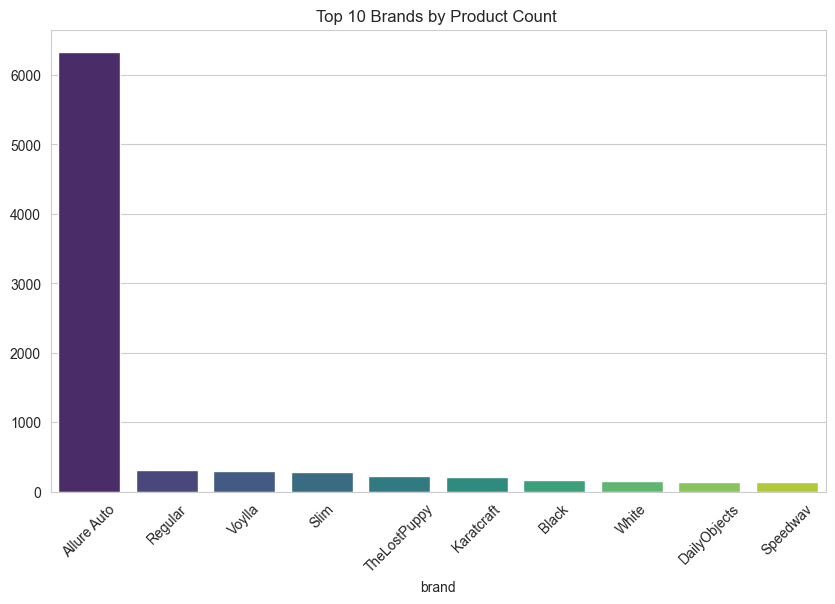

In [9]:
top_brands=df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.index,y=top_brands.values,palette='viridis')
plt.xticks(rotation=45)
plt.title("Top 10 Brands by Product Count ")
plt.show()

3. Average Discount by Brand

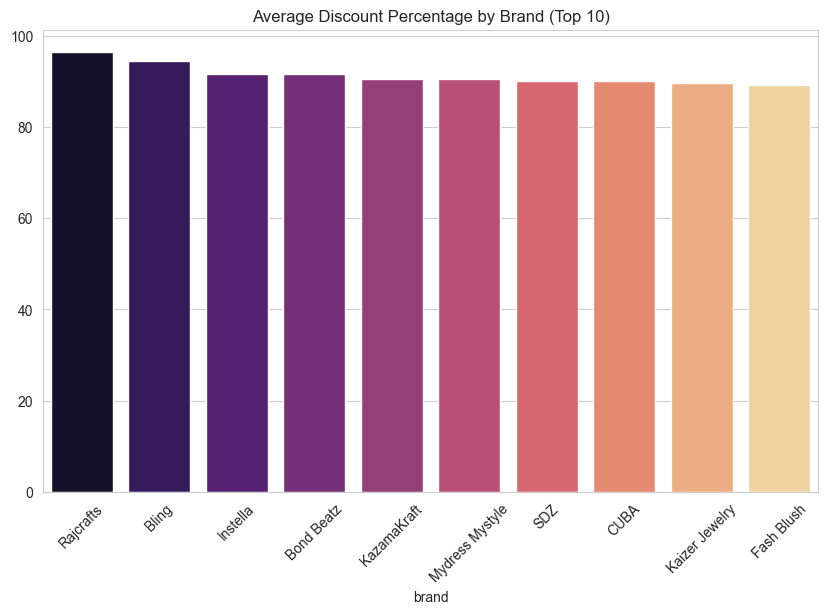

In [10]:
avg_discount=df.groupby('brand')['discount_percent'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_discount.index,y=avg_discount.values,palette='magma')
plt.xticks(rotation=45)
plt.title('Average Discount Percentage by Brand (Top 10)')
plt.show()

**Clustring Projects**

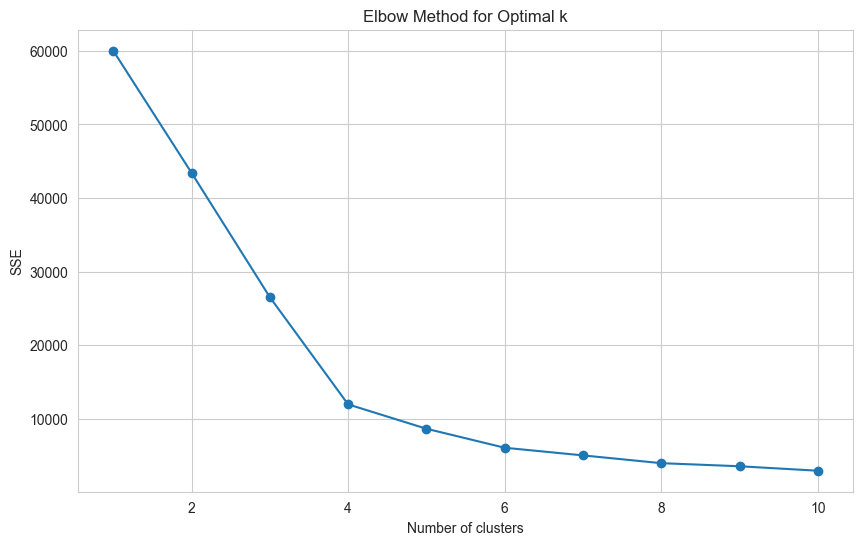

In [11]:
features=df[['retail_price', 'discounted_price','discount_percent']]
scaler=StandardScaler()
features_scaled=scaler.fit_transform(features)

#Elbow method
sse=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(features_scaled)
    sse.append(km.inertia_)
plt.plot(range(1,11),sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()       

 kmeans clustring

In [12]:

Kmeans=KMeans(n_clusters=5,random_state=42)
df['cluster']=Kmeans.fit_predict(features_scaled)

PCA for visualization

With 5 clusters, you can interpret:

🔹 Product Clustering Example

Cluster 0 (Red): Very low-price, high-discount items → “Mass budget deals”

Cluster 1 (Blue): Mid-price products with medium discounts → “Mid-market items”

Cluster 2 (Green): Premium products with low discounts → “Luxury segment”

Cluster 3 (Purple): Seasonal or special-category items (e.g., festive sales)

Cluster 4 (Orange): Highly discounted clearance stock

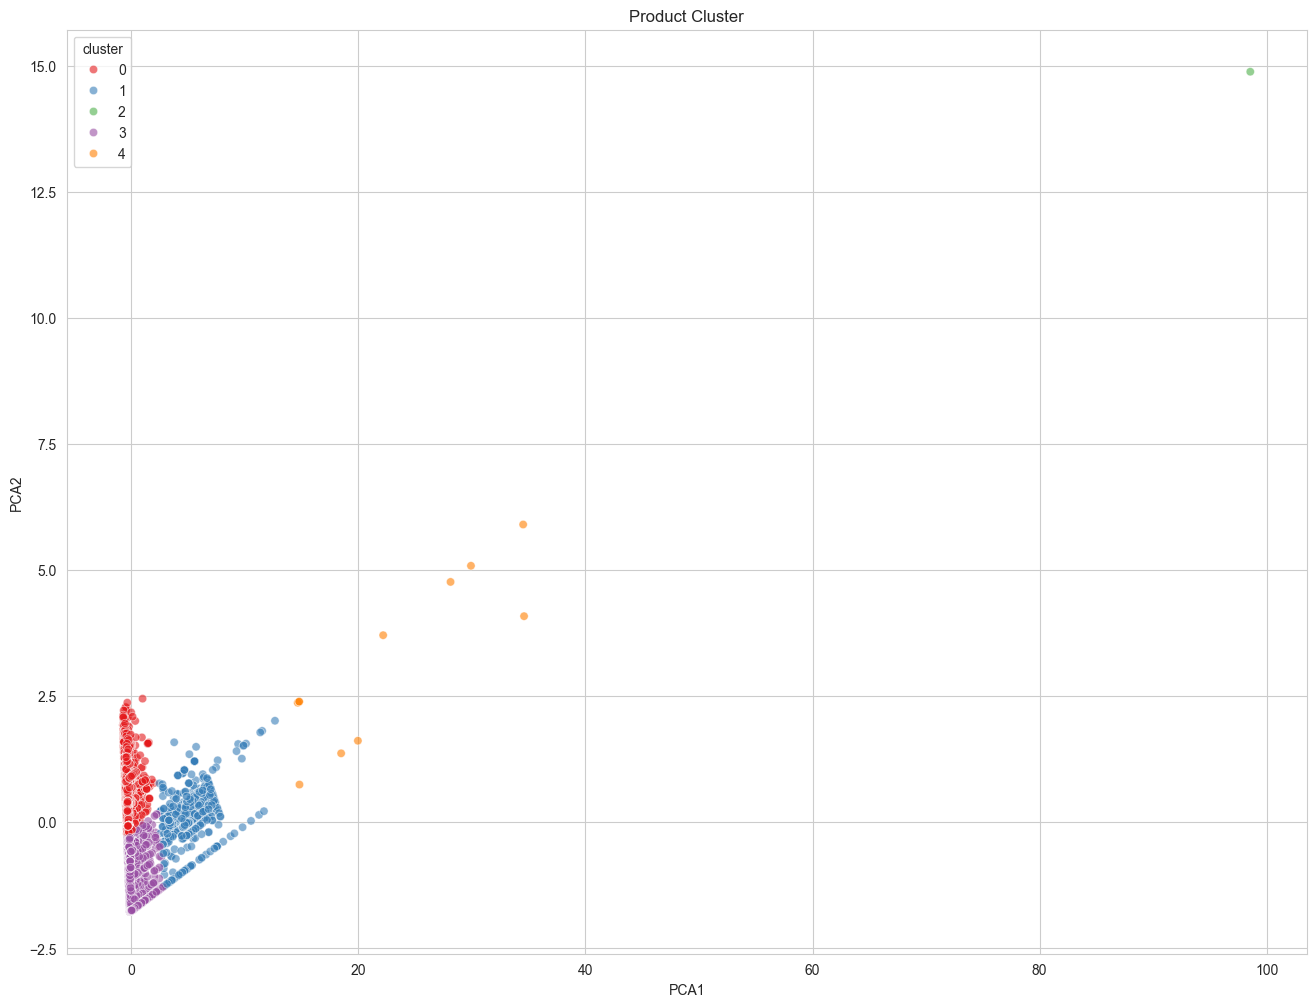

In [13]:
pca=PCA(n_components=2)
components=pca.fit_transform(features_scaled)
df['PCA1']=components[:,0]
df['PCA2']=components[:,1]


plt.figure(figsize=(16,12))
sns.scatterplot(x='PCA1',y='PCA2',hue='cluster',data=df,palette='Set1',alpha=.6)
plt.title('Product Cluster')
plt.show()


**Supervised Learning**

Predict “Discount Amount”

In [14]:

# keep only dicounted products
df_discounted=df[df['discount']>0].copy()

In [15]:
# Encode Categorical features
le_brand=LabelEncoder()
df_discounted['brand_encoded']=le_brand.fit_transform(df_discounted['brand'])


le_category=LabelEncoder()
df_discounted['category_encoded']=le_category.fit_transform(df_discounted['product_category_tree'])



Optional: historical discount per category

In [16]:
df_discounted['category_avg_discount']=df_discounted.groupby('product_category_tree')['discount'].mean().to_dict()
df_discounted['category_encoded']=df_discounted['product_category_tree'].map(category_avg_discount)

NameError: name 'category_avg_discount' is not defined

Prepare Features and Target

In [ ]:
X = df_discounted[['retail_price', 'brand_encoded', 'category_encoded', 'category_avg_discount']]
y = df_discounted['discount']

Train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Train Random Forest Regressor

In [ ]:
rf_model=RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(X_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred=rf_model.predict(X_test)

Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [ ]:
print(f'Mean Absolute Error: {mae}')


Mean Absolute Error: 114.99099265197455


In [ ]:
print("rmse",rmse)

rmse 441.72623233666474


In [ ]:
print('r2',r2)

r2 0.9675935114696915


Feature Importance

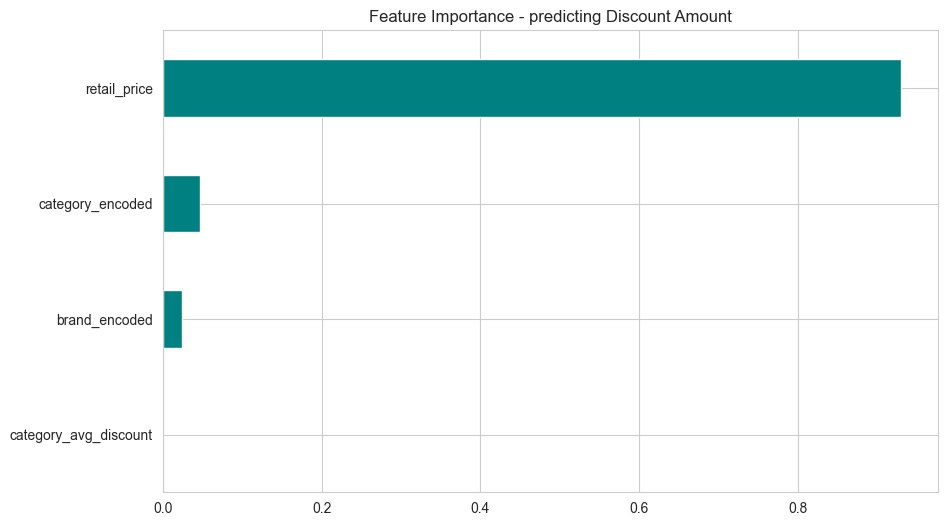

In [ ]:
importances=pd.Series(rf_model.feature_importances_,index=X.columns)
importances.sort_values().plot(kind='barh',color='teal')
plt.title('Feature Importance - predicting Discount Amount')
plt.show()

Actual vs Predicted Discount Plot

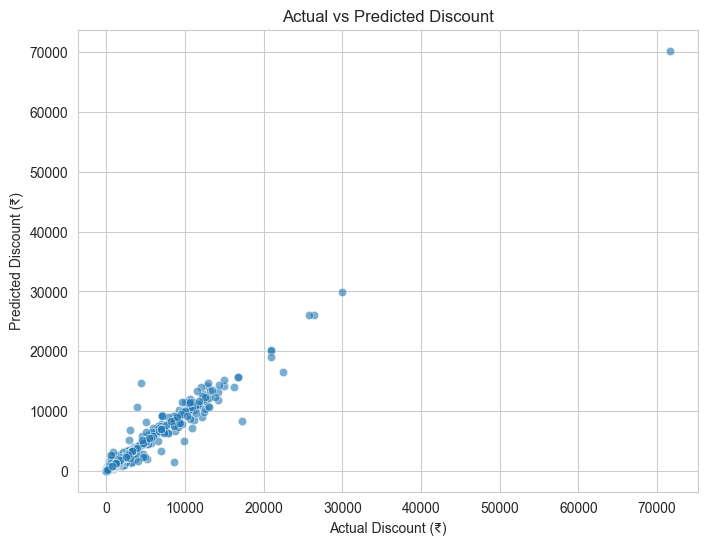

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Discount (₹)")
plt.ylabel("Predicted Discount (₹)")
plt.title("Actual vs Predicted Discount")
plt.show()

Dashboard of Top discounted Product

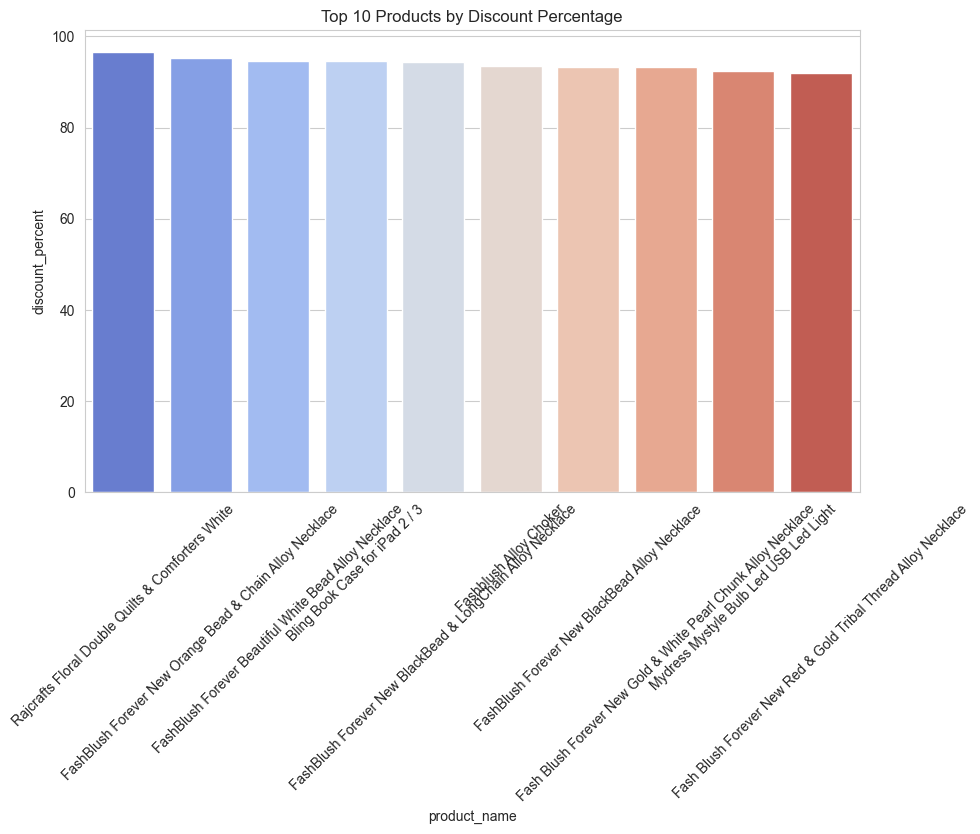

In [ ]:
top_discounted=df.sort_values('discount_percent',ascending=False).head(10)
sns.barplot(x='product_name',y='discount_percent',data=top_discounted,palette='coolwarm')
plt.title('Top 10 Products by Discount Percentage')
plt.xticks(rotation=45)
plt.show()